# Import Libraries & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset final
df_raw = pd.read_csv("data/processed/dataset_rekomendasi_final.csv")
print(f"Dataset Shape: {df_raw.shape}")
df_raw.head(2)

Dataset Shape: (1294, 23)


,id,name,city,country,rating,indoor_outdoor,opening_time,gmaps_link,features_text,combined_features,...,photo_link_1,photo_link_2,photo_link_3,photo_link_4,photo_link_5,review_1,review_2,review_3,review_4,review_5
0,ChIJM5cxndM3zDER7WuP_cN-omg,Aquaria KLCC,Kuala Lumpur,Malaysia,4.3,Outdoor,Monday: 10:00 AM – 8:00 PM | Tuesday: 10:00 AM...,https://maps.google.com/?cid=75397281064093890...,aquarium tourist attraction museum point of in...,aquarium tourist attraction museum point of in...,...,https://maps.googleapis.com/maps/api/place/pho...,https://maps.googleapis.com/maps/api/place/pho...,https://maps.googleapis.com/maps/api/place/pho...,https://maps.googleapis.com/maps/api/place/pho...,https://maps.googleapis.com/maps/api/place/pho...,It is easily one of the best spots in the city...,Year 2025 ended with a wonderful time at Aquar...,​I recently had an absolutely fantastic experi...,Visited Aquaria KLCC via Klook at SGD 17.85 — ...,"Had a wonderful experience, especially with ki..."
1,ChIJu8zWwchJzDERhcsx4AhQ1oo,KL Bird Park,Kuala Lumpur,Malaysia,4.4,Outdoor,Monday: 9:00 AM – 5:30 PM | Tuesday: 9:00 AM –...,https://maps.google.com/?cid=10004271621301455...,wildlife park zoo tourist attraction park poin...,wildlife park zoo tourist attraction park poin...,...,https://maps.googleapis.com/maps/api/place/pho...,https://maps.googleapis.com/maps/api/place/pho...,https://maps.googleapis.com/maps/api/place/pho...,https://maps.googleapis.com/maps/api/place/pho...,https://maps.googleapis.com/maps/api/place/pho...,I recently visited KL Bird Park with my 2-year...,KL Bird Park is a fantastic attraction and one...,Sooo much fun! This place was so worth it. The...,"It’s a wonderful place for children, with a wi...",Very large beautiful bird park with so much va...


# Check Missing Values & Data Types

In [6]:
print("=== INFO DATA TYPES & MISSING VALUES ===")
df_raw.info()

print("\n=== MISSING VALUES COUNT PARSING ===")
print(df_raw.isnull().sum())

=== INFO DATA TYPES & MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294 entries, 0 to 1293
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1294 non-null   object 
 1   name               1294 non-null   object 
 2   city               1294 non-null   object 
 3   country            1294 non-null   object 
 4   rating             1294 non-null   float64
 5   indoor_outdoor     1294 non-null   object 
 6   opening_time       1294 non-null   object 
 7   gmaps_link         1294 non-null   object 
 8   features_text      1294 non-null   object 
 9   combined_features  1294 non-null   object 
 10  latitude           1292 non-null   float64
 11  longitude          1292 non-null   float64
 12  phone_number       1292 non-null   object 
 13  photo_link_1       1294 non-null   object 
 14  photo_link_2       1294 non-null   object 
 15  photo_link_3       1294 non-nul

# Geospatial Lat/Long Sanity Check

In [4]:
# Memastikan koordinat tidak ada yang bernilai ekstrem atau korup
print("=== GEOSPATIAL COORDINATES STATS ===")
print(df_raw[['latitude', 'longitude']].describe())

# Cek jika ada koordinat yang bernilai 0 atau mencurigakan
zero_coords = df_raw[(df_raw['latitude'] == 0) | (df_raw['longitude'] == 0)]
print(f"\nJumlah baris dengan koordinat 0: {len(zero_coords)}")

=== GEOSPATIAL COORDINATES STATS ===
          latitude    longitude
count  1292.000000  1292.000000
mean     16.428777    62.122307
std      28.773288    73.224130
min     -37.867815  -122.581118
25%      -6.227384     9.187943
50%       8.301963   103.809544
75%      48.058788   115.273241
max      53.565294   151.295988

Jumlah baris dengan koordinat 0: 0


# Distribution of Indoor vs Outdoor

/tmp/ipykernel_1386/862592027.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='indoor_outdoor', palette='Set2')


Text(0.5, 1.0, 'Distribution of Indoor vs Outdoor')

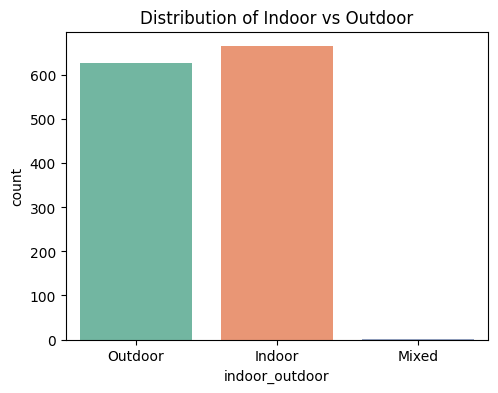

In [12]:
plt.figure(figsize=(12, 4))

# Plot Indoor/Outdoor
plt.subplot(1, 2, 1)
sns.countplot(data=df_raw, x='indoor_outdoor', palette='Set2')
plt.title('Distribution of Indoor vs Outdoor')


# Distribution of Ratings

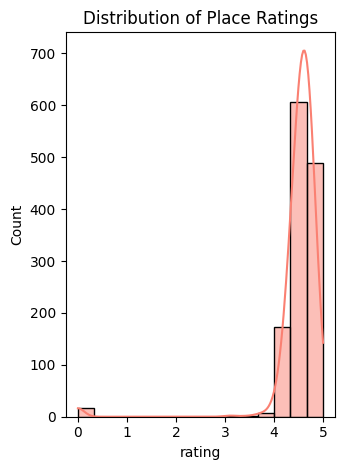

In [13]:
# Plot Ratings
plt.subplot(1, 2, 2)
sns.histplot(data=df_raw, x='rating', kde=True, bins=15, color='salmon')
plt.title('Distribution of Place Ratings')

plt.tight_layout()
plt.show()

# Inspect Google Maps Opening Time Format

In [14]:
print("=== SAMPLE GOOGLE MAPS OPENING TIME ===")
for i, val in enumerate(df_raw['opening_time'].dropna().head(3)):
    print(f"Sample {i+1}:\n{val}\n")

=== SAMPLE GOOGLE MAPS OPENING TIME ===
Sample 1:
Monday: 10:00 AM – 8:00 PM | Tuesday: 10:00 AM – 8:00 PM | Wednesday: 10:00 AM – 8:00 PM | Thursday: 10:00 AM – 8:00 PM | Friday: 10:00 AM – 8:00 PM | Saturday: 9:00 AM – 9:00 PM | Sunday: 9:00 AM – 9:00 PM

Sample 2:
Monday: 9:00 AM – 5:30 PM | Tuesday: 9:00 AM – 5:30 PM | Wednesday: 9:00 AM – 5:30 PM | Thursday: 9:00 AM – 5:30 PM | Friday: 9:00 AM – 5:30 PM | Saturday: 9:00 AM – 5:30 PM | Sunday: 9:00 AM – 5:30 PM

Sample 3:
Monday: Open 24 hours | Tuesday: Open 24 hours | Wednesday: Open 24 hours | Thursday: Open 24 hours | Friday: Open 24 hours | Saturday: Open 24 hours | Sunday: Open 24 hours

